In [1]:
print("Hello, Jupyter!")

Hello, Jupyter!


# Week 2 Summary: NumPy, Pandas, Gradient Descent, Loss Functions

## 1. Sensor Data Generation and Standardization

In [2]:
import numpy as np

np.random.seed(42)
X = np.random.normal(loc=25, scale=3, size=(1000, 4))

def standardize_sensors(X: np.ndarray) -> np.ndarray:
    """Standardize each column of the input array to mean 0 and std 1.

    Args:
    ----
        X: Input array of shape (n_samples, n_features).

    Returns:
    -------
        Standardized array with the same shape as X.
    """
    col_mean = X.mean(axis=0)
    col_std = X.std(axis=0)
    X_std = (X - col_mean) / col_std
    return X_std

X_std = standardize_sensors(X)

print("mean after standardization:", X_std.mean(axis=0))
print("std after standardization:", X_std.std(axis=0))

mean after standardization: [-5.10747000e-15  7.52931051e-15 -3.25073302e-15 -5.57959234e-15]
std after standardization: [1. 1. 1. 1.]


## 2. Pandas: Missing Values, Aggregation, and Filtering

In [3]:
import pandas as pd

df = pd.DataFrame(X, columns=["temperature", "humidity", "pressure", "vibration"])
df["sensor_id"] = np.random.choice([1, 2, 3, 4, 5], size=1000)

sensor_means = df.groupby("sensor_id").mean()
print(sensor_means)

           temperature   humidity   pressure  vibration
sensor_id                                              
1            25.191917  25.173947  25.089325  24.643996
2            24.782043  24.741811  24.875032  25.075249
3            25.111285  25.207586  25.013914  25.387974
4            25.337141  25.277955  24.872719  25.247906
5            25.093466  25.046475  25.051445  25.093039


In [4]:
np.random.seed(0)
missing_mask = np.random.random(df.shape) < 0.05
df_missing = df.mask(missing_mask)

print("Missing values per column:")
print(df_missing.isnull().sum())

df_ffill = df_missing.ffill()
df_mean = df_missing.fillna(df_missing.mean())

print("After ffill:", df_ffill.isnull().sum().sum())
print("After mean fill:", df_mean.isnull().sum().sum())

Missing values per column:
temperature    50
humidity       53
pressure       51
vibration      53
sensor_id      48
dtype: int64
After ffill: 0
After mean fill: 0


In [5]:
high_temp = df[df["temperature"] > 28]
print("High temperature rows:", high_temp.shape[0])

High temperature rows: 146


## 3. Visualization: Matplotlib and Plotly

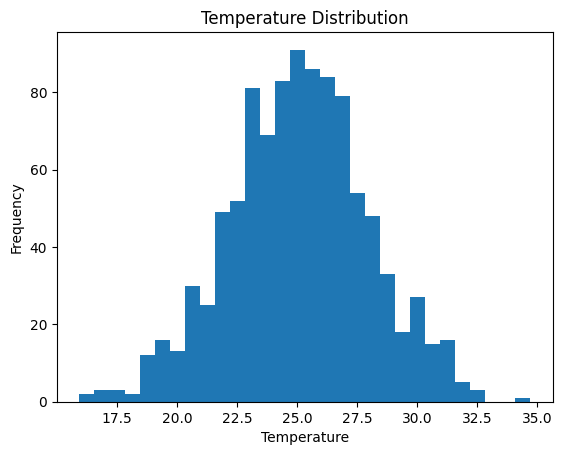

In [6]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["temperature"], bins=30)
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.title("Temperature Distribution")
plt.show()

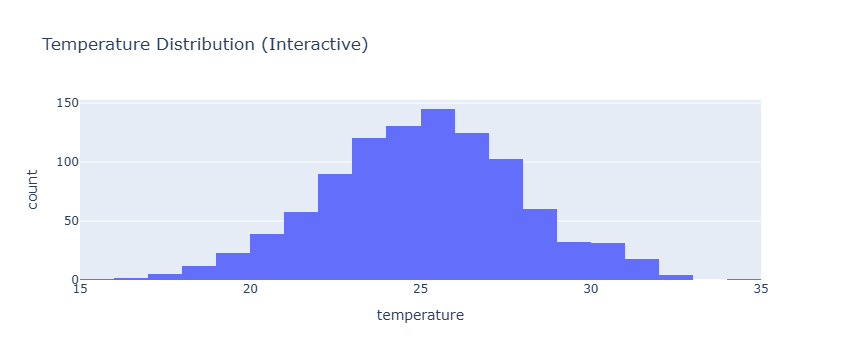

In [7]:
import plotly.express as px

fig = px.histogram(df, x="temperature", nbins=30, title="Temperature Distribution (Interactive)")
fig.show()

## 4. Gradient Descent: Batch vs SGD vs Mini-batch

In [8]:
np.random.seed(42)

N = 500
true_w = 3.0
true_b = 5.0
x_gd = np.random.normal(0, 2, size=N)
noise_gd = np.random.normal(0, 1, size=N)
y_gd = true_w * x_gd + true_b + noise_gd

def gradient_descent_batch(x, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    n = len(x)
    losses = []
    for epoch in range(epochs):
        y_pred = w * x + b
        error = y_pred - y
        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)
        w -= lr * dw
        b -= lr * db
        losses.append(np.mean(error ** 2))
    return w, b, losses

w_batch, b_batch, losses_batch = gradient_descent_batch(x_gd, y_gd, lr=0.01, epochs=1000)
print(f"Batch GD (1000 epochs): w={w_batch:.3f}, b={b_batch:.3f}")

Batch GD (1000 epochs): w=2.962, b=5.032


## 5. Loss Function Comparison: MSE vs MAE vs Huber

In [9]:
def compute_loss(y_true, y_pred, kind, delta=1.0):
    error = y_pred - y_true
    if kind == "mse":
        return error ** 2
    elif kind == "mae":
        return np.abs(error)
    elif kind == "huber":
        abs_error = np.abs(error)
        quadratic = 0.5 * error ** 2
        linear = delta * (abs_error - 0.5 * delta)
        return np.where(abs_error <= delta, quadratic, linear)
    else:
        raise ValueError(f"Unknown loss kind: {kind}")

y_true_test = np.array([10.0])
y_pred_test = np.array([12.0])
print("MSE:", compute_loss(y_true_test, y_pred_test, "mse"))
print("MAE:", compute_loss(y_true_test, y_pred_test, "mae"))
print("Huber:", compute_loss(y_true_test, y_pred_test, "huber"))

MSE: [4.]
MAE: [2.]
Huber: [1.5]
